In [112]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot

### Load in Data

In [113]:
NARG_INFO = {
    "KO": "K00370",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00370_v1.tsv"
}

NIRB_INFO = {
    "KO": "K00362",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00362_v1.tsv"
}

NATIVE_IDXS = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
NATIVE_PHS = np.array([5.0, 5.3, 5.41, 5.8, 6.15, 6.3, 6.5, 6.75, 6.9,  7.1])
PERTURBED_PHS = np.linspace(3.8, 8.4, 11)

OUTDIR = "../out/model_regression/nar"
IMGDIR = f"{OUTDIR}/images"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

def texify(param_name):
    return {
        "gamma_A": "\\gamma_{{A}}", 
        "gamma_I": "\\gamma_{{I}}", 
        "r_A": "r_{{A}}", 
        "r_I1": "r_{{I1}}", 
        "r_I2": "r_{{I2}}", 
        "K_A": "K_{{A}}", 
        "K_I": "K_{{I}}", 
        "mu": "\\mu", 
    }[param_name]

t_data_drug = np.linspace(0, 19, 20)

soils = [
    'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 
    'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'
]



def load_orf_groups(fpath) -> tuple[dict[int:str], np.ndarray[int]]:
    groups = {}
    idxs = []
    with open(fpath, "r") as f:
        csvreader = csv.reader(f, delimiter=" ")
        for row in csvreader:  # process each row
            orf = row[0]
            gidx = int(row[1])
            if gidx in groups:
                groups[gidx].append(orf)
            else:
                groups[gidx] = [orf]
                idxs.append(gidx)
    return groups, np.sort(idxs)

##############################################################################
##  Collect narG data

# Load ORF groups for narG
groups, group_idxs = load_orf_groups(NARG_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='None', 
            map='09',
        )
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,11), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,11), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nar_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_pos_t9 = np.zeros([10, 11, len(group_idxs)])
nar_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_neg_t9 = np.zeros([10, 11, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nar_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nar_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nar_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nar_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]

##############################################################################
##  Collect nirB data

# Load ORF groups for nirB
groups, group_idxs = load_orf_groups(NIRB_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='None', 
            map='09',
        )
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,11), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,11), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nir_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_pos_t9 = np.zeros([10, 11, len(group_idxs)])
nir_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_neg_t9 = np.zeros([10, 11, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nir_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nir_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nir_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nir_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]


Group 1: 18 ORFs
Group 2: 4 ORFs
Group 3: 14 ORFs
Group 4: 21 ORFs
  Total: 57
Group 1: 24 ORFs
Group 2: 15 ORFs
Group 3: 10 ORFs
Group 4: 13 ORFs
  Total: 62


In [114]:
##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_pos_t0 = nar_exp_chl_pos_t0 / np.sum(nar_exp_chl_pos_t0, -1)[...,None]
nar_rel_exp_chl_pos_t0 = nar_rel_exp_chl_pos_t0[:, np.newaxis, :]
nar_rel_exp_chl_pos_t0 = np.broadcast_to(nar_rel_exp_chl_pos_t0, (10, 11, 4))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t0 = nir_exp_chl_pos_t0 / np.sum(nir_exp_chl_pos_t0, -1)[...,None]
nir_rel_exp_chl_pos_t0 = nir_rel_exp_chl_pos_t0[:, np.newaxis, :]
nir_rel_exp_chl_pos_t0 = np.broadcast_to(nir_rel_exp_chl_pos_t0, (10, 11, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t9 = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_neg_t0 = nar_exp_chl_neg_t0 / np.sum(nar_exp_chl_neg_t0, -1)[...,None]
nar_rel_exp_chl_neg_t0 = nar_rel_exp_chl_neg_t0[:, np.newaxis, :]
nar_rel_exp_chl_neg_t0 = np.broadcast_to(nar_rel_exp_chl_neg_t0, (10, 11, 4))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t0 = nir_exp_chl_neg_t0 / np.sum(nir_exp_chl_neg_t0, -1)[...,None]
nir_rel_exp_chl_neg_t0 = nir_rel_exp_chl_neg_t0[:, np.newaxis, :]
nir_rel_exp_chl_neg_t0 = np.broadcast_to(nir_rel_exp_chl_neg_t0, (10, 11, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_neg_t9 = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t9 = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]

X_NAR_CHL_POS = np.concatenate([nar_rel_exp_chl_pos_t0, nar_rel_exp_chl_pos_t9], axis = -1)
X_NIR_CHL_POS = np.concatenate([nir_rel_exp_chl_pos_t0, nir_rel_exp_chl_pos_t9], axis = -1)
X_NAR_CHL_NEG = np.concatenate([nar_rel_exp_chl_neg_t0, nar_rel_exp_chl_neg_t9], axis = -1)
X_NIR_CHL_NEG = np.concatenate([nir_rel_exp_chl_neg_t0, nir_rel_exp_chl_neg_t9], axis = -1)

### Regression target (Y, model paramters)

regress so that narG variants predict $\tilde{x}_0$ (CHL+) and $\tilde{C}_0$ (CHL-) and nirB variants predict $\eta \tilde{x}_0$ (CHL+) and $\eta \tilde{C}_0$ (CHL-).

In [115]:
eta_chl_pos = pd.read_csv('../out/metabolic_parameters/eta+.tsv', sep = '\t', header = None).values
eta_chl_neg = pd.read_csv('../out/metabolic_parameters/eta-.tsv', sep = '\t', header = None).values
x0 = pd.read_csv('../out/metabolic_parameters/x0.tsv', sep = '\t', header = None).values
c0 = pd.read_csv('../out/metabolic_parameters/c0.tsv', sep = '\t', header = None).values

eta_x0 = eta_chl_pos*x0
eta_c0 = eta_chl_neg*c0

Y_CHL_POS = np.concatenate([x0[..., np.newaxis], eta_x0[..., np.newaxis]], axis = -1)
Y_CHL_NEG = np.concatenate([c0[..., np.newaxis], eta_c0[..., np.newaxis]], axis = -1)

### Perform an initial LASSO on all of the data

### Start with CHL+

In [116]:
##############################################################################
### Lasso for NAR, NIR CHL+ case

ALPHA = 0.0001  # Regularization strength

clf_nar = []
clf_nir = []
for i in range(11):
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NAR_CHL_POS[:,i,:], Y_CHL_POS[:,i,0])
    clf_nar.append(clf)
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NIR_CHL_POS[:,i,:], Y_CHL_POS[:,i,1])
    clf_nir.append(clf)

print("--------------------------------------------------")
print("NAR")
for i in range(11):
    print(f"Coefficients {clf_nar[i].coef_.shape}:\n", clf_nar[i].coef_)
    print(f"Intercepts: {clf_nar[i].intercept_.shape}\n", clf_nar[i].intercept_)
print("--------------------------------------------------")

print("--------------------------------------------------")
print("NIR")
for i in range(11):
    print(f"Coefficients {clf_nir[i].coef_.shape}:\n", clf_nir[i].coef_)
    print(f"Intercepts: {clf_nir[i].intercept_.shape}\n", clf_nir[i].intercept_)
print("--------------------------------------------------")


--------------------------------------------------
NAR
Coefficients (8,):
 [-0.04292422  0.          0.00382128 -0.          0.07135607  0.06166975
 -0.         -0.02918583]
Intercepts: ()
 0.02805046762771759
Coefficients (8,):
 [ 0.          0.          0.0834812  -0.0126745   0.05206516  0.
 -0.07607971 -0.        ]
Intercepts: ()
 0.013820352336678814
Coefficients (8,):
 [ 0.         -0.          0.00077692 -0.03540759 -0.          0.
  0.         -0.0749247 ]
Intercepts: ()
 0.0891966203770628
Coefficients (8,):
 [-0.          0.          0.02341997 -0.0300687   0.          0.
 -0.         -0.06750922]
Intercepts: ()
 0.08666270840805515
Coefficients (8,):
 [ 0.         -0.          0.04505117 -0.0226163  -0.          0.00991639
  0.         -0.05939405]
Intercepts: ()
 0.07968496925415333
Coefficients (8,):
 [-0.02847143 -0.          0.03129764  0.          0.          0.
 -0.         -0.11085523]
Intercepts: ()
 0.1168677885616064
Coefficients (8,):
 [-0.02929626 -0.          0.

### Collect Predicted Parameters

In [117]:
x0_grid = np.zeros((10,11))
x0_eta_grid = np.zeros((10,11))
X_NIR_T0 = nir_rel_exp_chl_pos_t0
X_NAR_T0 = nar_rel_exp_chl_pos_t0
X_NIR_T9 = nir_rel_exp_chl_pos_t9
X_NAR_T9 = nar_rel_exp_chl_pos_t9
for native in tqdm.trange(10, desc="native", leave=False):
        for pert in tqdm.trange(11, desc="perturbed", leave=False):
            x0_pred = 0
            x0_eta_pred = 0
            for i in range(len(group_idxs)):
                x0_pred += X_NAR_T0[native, pert, i]*clf_nar[pert].coef_[i]
                x0_eta_pred += X_NIR_T0[native, pert, i]*clf_nir[pert].coef_[i]  
                x0_pred += X_NAR_T9[native, pert, i]*clf_nar[pert].coef_[i + len(group_idxs)]
                x0_eta_pred += X_NIR_T9[native, pert, i]*clf_nir[pert].coef_[i + len(group_idxs)]  
            x0_pred += clf_nar[pert].intercept_
            x0_eta_pred += clf_nir[pert].intercept_
            y_pred = [x0_pred, x0_eta_pred]
            x0_grid[native, pert] = x0_pred
            x0_eta_grid[native, pert] = x0_eta_pred


native:   0%|          | 0/10 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

...

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

### Compare Observed with Predicted

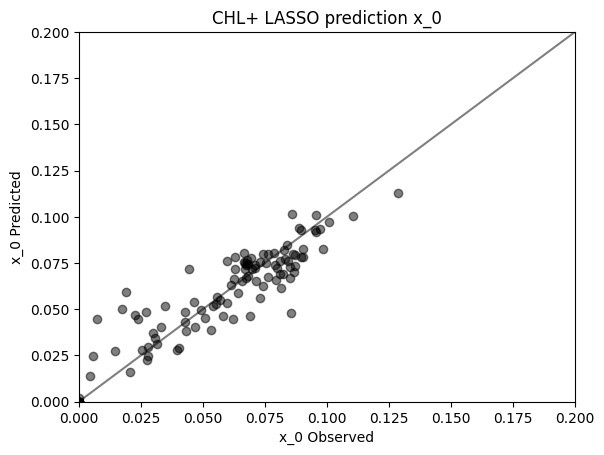

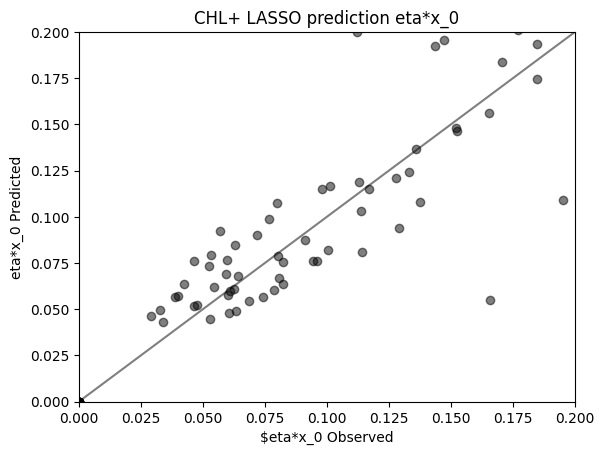

In [118]:

x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_POS[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_POS[native,pert, 1]
        y_nar[10*native + pert] = x0_grid[native, pert]
        y_nir[10*native + pert] = x0_eta_grid[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('x_0 Observed')
plt.ylabel('x_0 Predicted')
plt.title('CHL+ LASSO prediction x_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$eta*x_0 Observed')
plt.ylabel('eta*x_0 Predicted')
plt.title('CHL+ LASSO prediction eta*x_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()


### Now CHL- 

In [119]:
##############################################################################
### Lasso for NAR, NIR CHL+ case

ALPHA = 0.0001  # Regularization strength

clf_nar = []
clf_nir = []
for i in range(11):
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NAR_CHL_NEG[:,i,:], Y_CHL_NEG[:,i,0])
    clf_nar.append(clf)
    clf = linear_model.Lasso(alpha=ALPHA)
    clf.fit(X_NIR_CHL_NEG[:,i,:], Y_CHL_NEG[:,i,1])
    clf_nir.append(clf)

print("--------------------------------------------------")
print("NAR")
for i in range(11):
    print(f"Coefficients {clf_nar[i].coef_.shape}:\n", clf_nar[i].coef_)
    print(f"Intercepts: {clf_nar[i].intercept_.shape}\n", clf_nar[i].intercept_)
print("--------------------------------------------------")

print("--------------------------------------------------")
print("NIR")
for i in range(11):
    print(f"Coefficients {clf_nir[i].coef_.shape}:\n", clf_nir[i].coef_)
    print(f"Intercepts: {clf_nir[i].intercept_.shape}\n", clf_nir[i].intercept_)
print("--------------------------------------------------")


--------------------------------------------------
NAR
Coefficients (8,):
 [ 0.00188127 -0.          0.         -0.00962926  0.         -0.
 -0.          0.        ]
Intercepts: ()
 0.007631056049668599
Coefficients (8,):
 [ 0.00228461 -0.          0.         -0.0005332   0.00922947  0.
 -0.         -0.00129397]
Intercepts: ()
 0.0019552036374733657
Coefficients (8,):
 [ 0.00275961  0.         -0.         -0.00607365  0.         -0.
  0.         -0.        ]
Intercepts: ()
 0.006499976797740762
Coefficients (8,):
 [ 0.00450446 -0.          0.         -0.00177292 -0.00399295  0.
  0.         -0.        ]
Intercepts: ()
 0.008336558514260016
Coefficients (8,):
 [ 0.00482523  0.         -0.         -0.00213544 -0.0114929   0.
  0.          0.        ]
Intercepts: ()
 0.020123997435927913
Coefficients (8,):
 [ 0.00681387 -0.          0.         -0.0026449  -0.          0.
 -0.         -0.        ]
Intercepts: ()
 0.010563654538241997
Coefficients (8,):
 [ 0.00201145 -0.          0.        

In [120]:
c0_grid = np.zeros((10,11))
c0_eta_grid = np.zeros((10,11))
X_NIR_T0 = nir_rel_exp_chl_neg_t0
X_NAR_T0 = nar_rel_exp_chl_neg_t0
X_NIR_T9 = nir_rel_exp_chl_neg_t9
X_NAR_T9 = nar_rel_exp_chl_neg_t9
for native in tqdm.trange(10, desc="native", leave=False):
        for pert in tqdm.trange(11, desc="perturbed", leave=False):
            c0_pred = 0
            c0_eta_pred = 0
            for i in range(len(group_idxs)):
                c0_pred += X_NAR_T0[native, pert, i]*clf_nar[pert].coef_[i]
                c0_eta_pred += X_NIR_T0[native, pert, i]*clf_nir[pert].coef_[i]  
                c0_pred += X_NAR_T9[native, pert, i]*clf_nar[pert].coef_[i + len(group_idxs)]
                c0_eta_pred += X_NIR_T9[native, pert, i]*clf_nir[pert].coef_[i + len(group_idxs)]  
            c0_pred += clf_nar[pert].intercept_
            c0_eta_pred += clf_nir[pert].intercept_
            y_pred = [c0_pred, c0_eta_pred]
            c0_grid[native, pert] = c0_pred
            c0_eta_grid[native, pert] = c0_eta_pred


native:   0%|          | 0/10 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

...

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

perturbed:   0%|          | 0/11 [00:00<?, ?it/s]

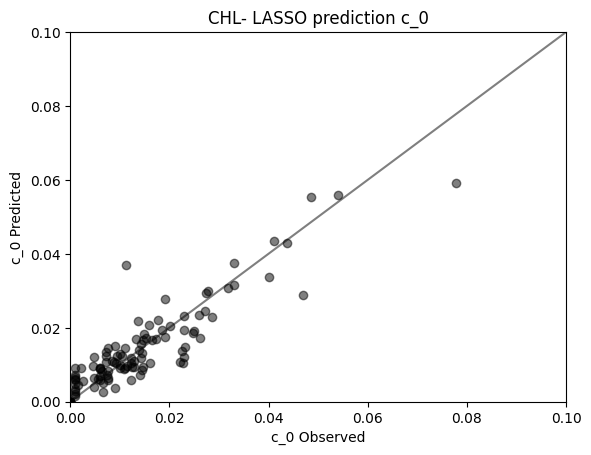

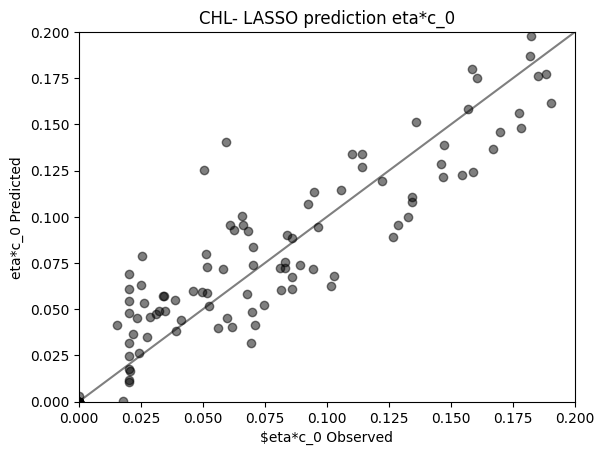

In [121]:

x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_NEG[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_NEG[native,pert, 1]
        y_nar[10*native + pert] = c0_grid[native, pert]
        y_nir[10*native + pert] = c0_eta_grid[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('c_0 Observed')
plt.ylabel('c_0 Predicted')
plt.title('CHL- LASSO prediction c_0')
plt.xlim(0,0.1)
plt.ylim(0,0.1)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('$eta*c_0 Observed')
plt.ylabel('eta*c_0 Predicted')
plt.title('CHL- LASSO prediction eta*c_0')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()


### Try a LOOCV on all of the data

In [122]:
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_absolute_percentage_error

ALPHA = 0.1 # Regularization strength
n_samples = X_NAR_CHL_POS.shape[0]  # How many native soils? 

# Store models and predictions for LOOCV
clf_nar_models = []  # Will store 11 lists (one per perturbation), each containing 10 models
clf_nir_models = []
nar_predictions = np.zeros_like(Y_CHL_POS[:, :, 0])  # Store predictions for evaluation
nir_predictions = np.zeros_like(Y_CHL_POS[:, :, 1])

# Loop over perturbations (11)
for i in range(11):
    nar_models_i = []
    nir_models_i = []
    
    # Loop over leave-one-out samples (10)
    for leave_out in range(n_samples):
        # Train NAR model (leave out 'leave_out' row)
        X_train_nar = np.delete(X_NAR_CHL_POS[:, i, :], leave_out, axis=0)
        Y_train_nar = np.delete(Y_CHL_POS[:, i, 0], leave_out)
        
        clf_nar = linear_model.Lasso(alpha=ALPHA)
        clf_nar.fit(X_train_nar, Y_train_nar)
        nar_models_i.append(clf_nar)
        
        # Predict on left-out sample
        nar_pred = clf_nar.predict(X_NAR_CHL_POS[leave_out, i, :].reshape(1, -1))
        nar_predictions[leave_out, i] = nar_pred
        
        # Train NIR model (leave out 'leave_out' row)
        X_train_nir = np.delete(X_NIR_CHL_POS[:, i, :], leave_out, axis=0)
        Y_train_nir = np.delete(Y_CHL_POS[:, i, 1], leave_out)
        
        clf_nir = linear_model.Lasso(alpha=ALPHA)
        clf_nir.fit(X_train_nir, Y_train_nir)
        nir_models_i.append(clf_nir)
        
        # Predict on left-out sample
        nir_pred = clf_nir.predict(X_NIR_CHL_POS[leave_out, i, :].reshape(1, -1))
        nir_predictions[leave_out, i] = nir_pred
    
    clf_nar_models.append(nar_models_i)
    clf_nir_models.append(nir_models_i)

# Evaluate performance (MSE per perturbation)
nar_mse = [mean_absolute_percentage_error(Y_CHL_POS[:, i, 0], nar_predictions[:, i]) for i in range(11)]
nir_mse = [mean_absolute_percentage_error(Y_CHL_POS[:, i, 1], nir_predictions[:, i]) for i in range(11)]

nar_predictions_chl_pos = nar_predictions
nir_predictions_chl_pos = nir_predictions

print("--------------------------------------------------")
print("NAR Mean Squared Errors (LOOCV):")
for i in range(11):
    print(f"Perturbation {i}: MSE = {nar_mse[i]:.4f}")
print("--------------------------------------------------")

print("NIR Mean Squared Errors (LOOCV):")
for i in range(11):
    print(f"Perturbation {i}: MSE = {nir_mse[i]:.4f}")
print("--------------------------------------------------")

--------------------------------------------------
NAR Mean Squared Errors (LOOCV):
Perturbation 0: MSE = 352.8078
Perturbation 1: MSE = 1.1335
Perturbation 2: MSE = 0.5706
Perturbation 3: MSE = 0.4660
Perturbation 4: MSE = 0.5674
Perturbation 5: MSE = 0.2730
Perturbation 6: MSE = 0.2188
Perturbation 7: MSE = 0.1677
Perturbation 8: MSE = 0.1662
Perturbation 9: MSE = 1.2092
Perturbation 10: MSE = 3.5192
--------------------------------------------------
NIR Mean Squared Errors (LOOCV):
Perturbation 0: MSE = 342743146.0243
Perturbation 1: MSE = 0.7542
Perturbation 2: MSE = 0.5242
Perturbation 3: MSE = 0.6271
Perturbation 4: MSE = 0.6130
Perturbation 5: MSE = 0.3935
Perturbation 6: MSE = 0.2484
Perturbation 7: MSE = 0.3173
Perturbation 8: MSE = 0.2169
Perturbation 9: MSE = 0.3453
Perturbation 10: MSE = 1070604.4006
--------------------------------------------------


/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/1764839798.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nar_predictions[leave_out, i] = nar_pred
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/1764839798.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nir_predictions[leave_out, i] = nir_pred
/var/folders/_1/szp4571s76d__d0kyyc1stgc0000gn/T/ipykernel_1288/1764839798.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  nar

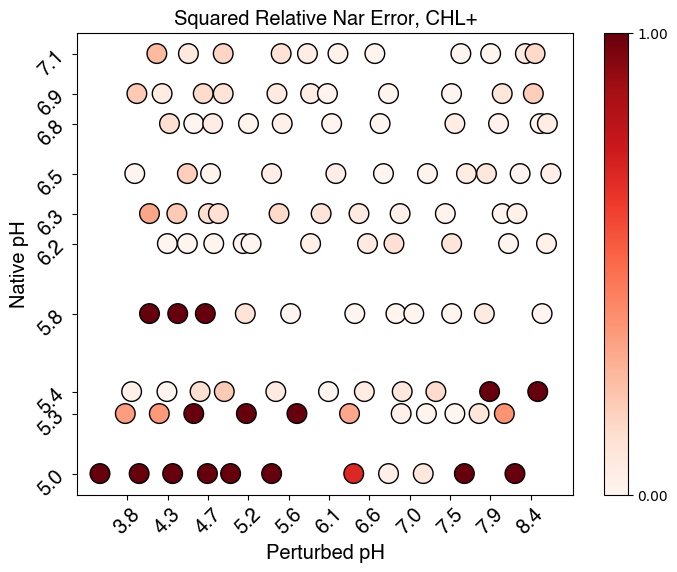

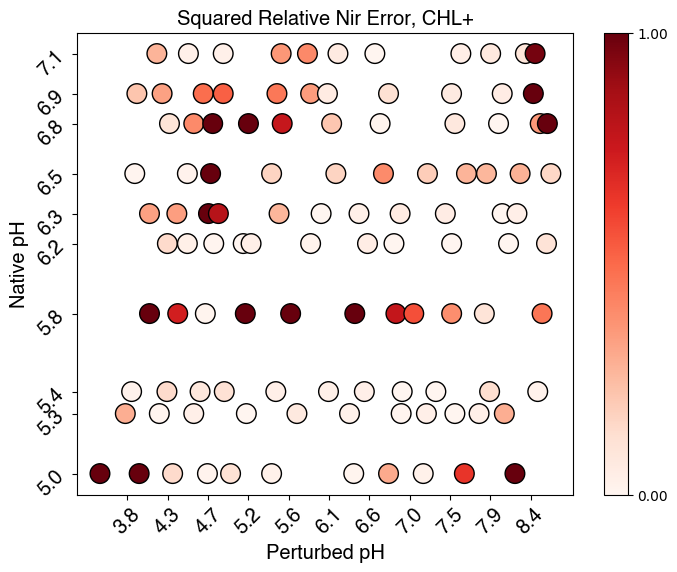

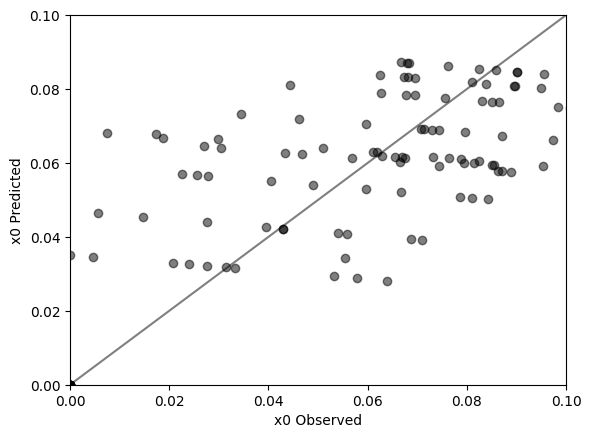

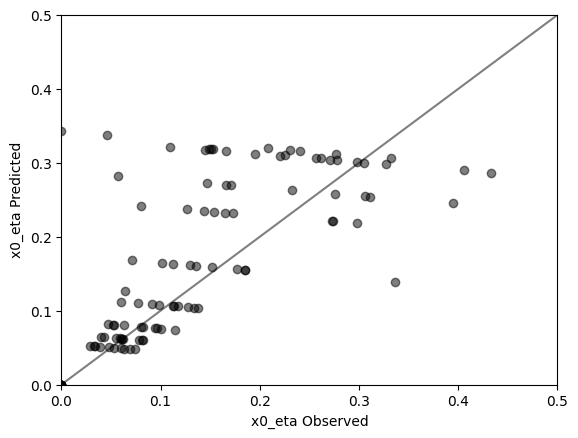

In [123]:
plot((nar_predictions - Y_CHL_POS[:, :, 0])**2/Y_CHL_POS[:, :, 0]**2, 'Squared Relative Nar Error, CHL+', cmap = 'Reds', vmin = 0, vmax = 1)
plot((nir_predictions - Y_CHL_POS[:, :, 1])**2/Y_CHL_POS[:, :, 1]**2, 'Squared Relative Nir Error, CHL+', cmap = 'Reds', vmin = 0, vmax = 1)


x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[10*native + pert] = Y_CHL_POS[native,pert, 0]
        x_nir[10*native + pert] = Y_CHL_POS[native,pert, 1]
        y_nar[10*native + pert] = nar_predictions_chl_pos[native, pert]
        y_nir[10*native + pert] = nir_predictions_chl_pos[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('x0 Observed')
plt.ylabel('x0 Predicted')
plt.xlim(0,0.1)
plt.ylim(0,0.1)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('x0_eta Observed')
plt.ylabel('x0_eta Predicted')
plt.xlim(0,0.5)
plt.ylim(0,0.5)
plt.show()


In [127]:
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

ALPHA = 0.1  # Regularization strength
n_samples = X_NAR_CHL_NEG.shape[0]  # How many native samples? 

# Store models and predictions for LOOCV
clf_nar_models = []  # Will store 11 lists (one per perturbation), each containing 10 models
clf_nir_models = []
nar_predictions = np.zeros_like(Y_CHL_NEG[:, :, 0])  # Store predictions for evaluation
nir_predictions = np.zeros_like(Y_CHL_NEG[:, :, 1])

# Loop over perturbations (11)
for i in range(11):
    nar_models_i = []
    nir_models_i = []
    
    # Loop over leave-one-out samples (10)
    for leave_out in range(n_samples):
        # Train NAR model (leave out 'leave_out' row)
        X_train_nar = np.delete(X_NAR_CHL_NEG[:, i, :], leave_out, axis=0)
        Y_train_nar = np.delete(Y_CHL_NEG[:, i, 0], leave_out)
        
        clf_nar = linear_model.Lasso(alpha=ALPHA)
        clf_nar.fit(X_train_nar, Y_train_nar)
        nar_models_i.append(clf_nar)
        
        # Predict on left-out sample
        nar_pred = clf_nar.predict(X_NAR_CHL_NEG[leave_out, i, :].reshape(1, -1))
        nar_predictions[leave_out, i] = nar_pred[0]
        
        # Train NIR model (leave out 'leave_out' row)
        X_train_nir = np.delete(X_NIR_CHL_NEG[:, i, :], leave_out, axis=0)
        Y_train_nir = np.delete(Y_CHL_NEG[:, i, 1], leave_out)
        
        clf_nir = linear_model.Lasso(alpha=ALPHA)
        clf_nir.fit(X_train_nir, Y_train_nir)
        nir_models_i.append(clf_nir)
        
        # Predict on left-out sample
        nir_pred = clf_nir.predict(X_NIR_CHL_NEG[leave_out, i, :].reshape(1, -1))
        nir_predictions[leave_out, i] = nir_pred[0]
    
    clf_nar_models.append(nar_models_i)
    clf_nir_models.append(nir_models_i)

# Evaluate performance (MSE per perturbation)
nar_mse = [mean_absolute_percentage_error(Y_CHL_NEG[:, i, 0], nar_predictions[:, i]) for i in range(11)]
nir_mse = [mean_absolute_percentage_error(Y_CHL_NEG[:, i, 1], nir_predictions[:, i]) for i in range(11)]

nar_predictions_chl_neg = nar_predictions
nir_predictions_chl_neg = nir_predictions

print("--------------------------------------------------")
print("NAR Mean Squared Errors (LOOCV):")
for i in range(11):
    print(f"Perturbation {i}: MSE = {nar_mse[i]:.4f}")
print("--------------------------------------------------")

print("NIR Mean Squared Errors (LOOCV):")
for i in range(11):
    print(f"Perturbation {i}: MSE = {nir_mse[i]:.4f}")
print("--------------------------------------------------")

--------------------------------------------------
NAR Mean Squared Errors (LOOCV):
Perturbation 0: MSE = 2.6262
Perturbation 1: MSE = 1.4535
Perturbation 2: MSE = 2.0458
Perturbation 3: MSE = 1.7211
Perturbation 4: MSE = 0.5920
Perturbation 5: MSE = 0.3693
Perturbation 6: MSE = 0.6882
Perturbation 7: MSE = 1.1368
Perturbation 8: MSE = 0.5411
Perturbation 9: MSE = 0.5117
Perturbation 10: MSE = 0.1310
--------------------------------------------------
NIR Mean Squared Errors (LOOCV):
Perturbation 0: MSE = 9574.3741
Perturbation 1: MSE = 0.7092
Perturbation 2: MSE = 1.3620
Perturbation 3: MSE = 1.1217
Perturbation 4: MSE = 0.5451
Perturbation 5: MSE = 0.7200
Perturbation 6: MSE = 0.9649
Perturbation 7: MSE = 1.4989
Perturbation 8: MSE = 0.6213
Perturbation 9: MSE = 0.4779
Perturbation 10: MSE = 0.5094
--------------------------------------------------


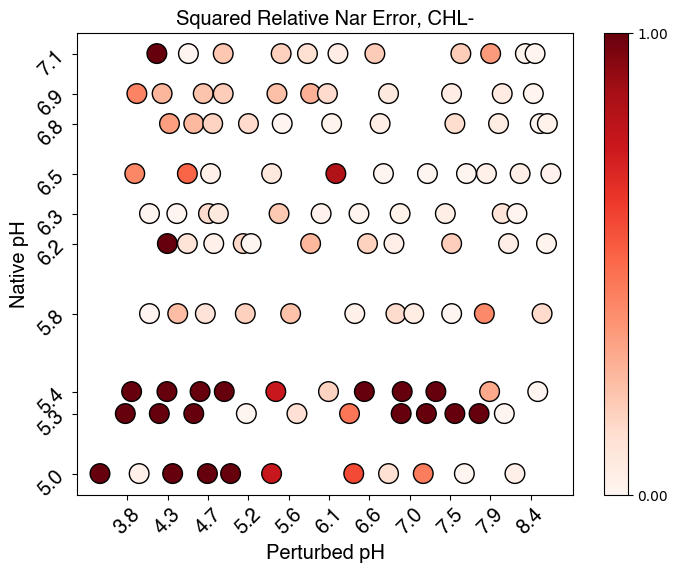

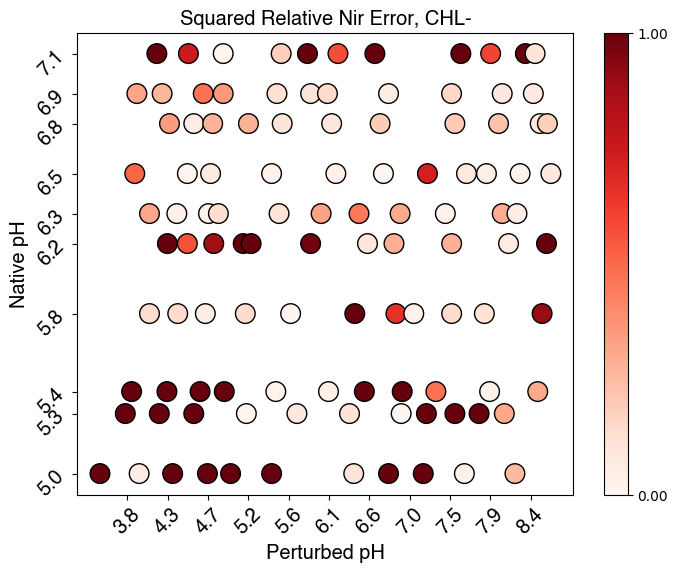

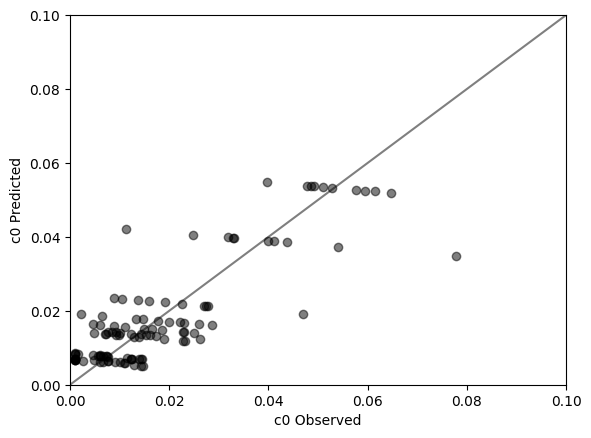

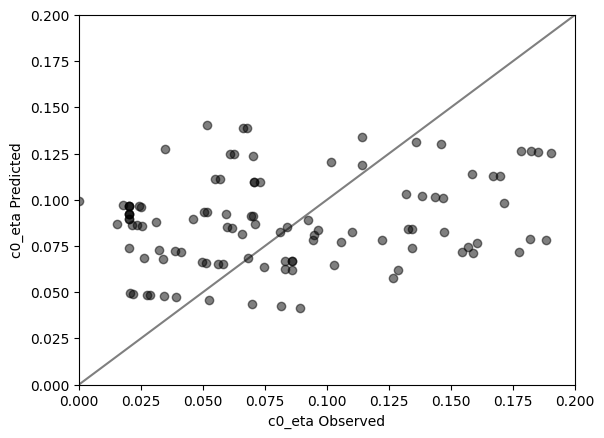

In [128]:
plot((nar_predictions - Y_CHL_NEG[:, :, 0])**2/Y_CHL_NEG[:, :, 0]**2, 'Squared Relative Nar Error, CHL-', cmap = 'Reds', vmin = 0, vmax = 1)
plot((nir_predictions - Y_CHL_NEG[:, :, 1])**2/Y_CHL_NEG[:, :, 1]**2, 'Squared Relative Nir Error, CHL-', cmap = 'Reds', vmin = 0, vmax = 1)

x_nar = np.zeros(110)
y_nar = np.zeros(110)
x_nir = np.zeros(110)
y_nir = np.zeros(110)
x = np.linspace(0,20,10)
y = np.linspace(0,20,10)
for native in range(10):
    for pert in range(11):
        x_nar[11*native + pert] = Y_CHL_NEG[native,pert, 0]
        x_nir[11*native + pert] = Y_CHL_NEG[native,pert, 1]
        y_nar[11*native + pert] = nar_predictions_chl_neg[native, pert]
        y_nir[11*native + pert] = nir_predictions_chl_neg[native, pert]
        
plt.scatter(x_nar, y_nar, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('c0 Observed')
plt.ylabel('c0 Predicted')
plt.xlim(0,0.1)
plt.ylim(0,0.1)
plt.show()
plt.scatter(x_nir, y_nir, color = 'Black', alpha = 0.5)
plt.plot(x,y, color = 'Black', alpha = 0.5)
plt.xlabel('c0_eta Observed')
plt.ylabel('c0_eta Predicted')
plt.xlim(0,0.2)
plt.ylim(0,0.2)
plt.show()